# Variational Inference for Bayesian Neural Networks (Bayes by Backprop)

**Variational Inference (VI)** is a powerful framework that turns Bayesian inference into an
optimization problem. Instead of computing the exact posterior distribution over model parameters
— which is intractable for neural networks — VI approximates it with a simpler, tractable
distribution $q(\boldsymbol{\theta} \mid \boldsymbol{\phi})$ by maximizing the **Evidence Lower
Bound (ELBO)**.

This notebook implements the **Bayes by Backprop** algorithm
([Blundell et al., 2015](https://arxiv.org/abs/1505.05424)), which applies variational inference
to train a Bayesian neural network (BNN) using standard gradient-based optimization. The key
ingredients are:

#### Key ideas

1. **Variational posterior**: Each weight $w$ is modeled by a Gaussian
   $q(w \mid \mu, \rho) = \mathcal{N}(\mu,\, \sigma^2)$ where $\sigma = \text{softplus}(\rho)$
   ensures positivity. The learnable parameters are $(\mu, \rho)$.

2. **Scale mixture prior**: The prior over each weight is a mixture of two zero-mean Gaussians
   $p(w) = \pi\, \mathcal{N}(0, \sigma_1^2) + (1 - \pi)\, \mathcal{N}(0, \sigma_2^2)$,
   which acts as a soft *spike-and-slab* prior encouraging a mix of large and small weights.

3. **Reparameterization trick**: To enable gradient-based optimization through the stochastic
   sampling step, we write $w = \mu + \sigma \odot \varepsilon$ with
   $\varepsilon \sim \mathcal{N}(0, I)$, making the randomness independent of the parameters.

4. **Monte Carlo KL divergence**: Since the KL divergence between the variational posterior and
   the mixture prior has no closed form, it is estimated via a single Monte Carlo sample per
   forward pass: $\text{KL} \approx \log q(w) - \log p(w)$.

5. **ELBO as loss**: The total training loss is the negative ELBO:
   $\mathcal{L} = \underbrace{\text{NLL}(y \mid x, \boldsymbol{\theta})}_{\text{data fit}} +
   \underbrace{\text{KL}\big[q(\boldsymbol{\theta}) \,\|\, p(\boldsymbol{\theta})\big]}_{\text{complexity cost}}$

The notebook demonstrates these ideas on a simple **1-D regression task**: learning a noisy
sinusoidal function and visualizing the model's epistemic uncertainty. All code uses **PyTorch**
and is fully self-contained.

For a conceptual introduction to variational inference, see
[this excellent blog post](https://lacerbi.github.io/blog/2024/vi-is-inference-is-optimization/).

### 1. Initial Setup

In [14]:
from __future__ import annotations

import math

import matplotlib.pyplot as plt
import numpy as np
import torch
import tqdm
from torch import nn
from torch.nn import functional as F

### 2. Dataset Generation

We construct a synthetic 1-D regression dataset:

- **Target function**: $f(x) = 10\sin(2\pi x)$, a scaled sinusoid that completes one full
  period over $[-0.5, 0.5]$.
- **Training set**: 1800 equally-spaced points in $[-0.5, 0.5]$ with additive Gaussian noise
  ($\sigma = 1.0$).

The relatively large noise level makes the task non-trivial and lets us observe how the BNN's
uncertainty estimates respond to noise in the data.

In [15]:
TRAIN_SIZE = 1800
NOISE_STD = 1.0

np.random.seed(42)


def f_sin(x: np.ndarray, sigma: float = 0.0) -> np.ndarray:
    """Noisy sinusoidal target: f(x) = 10 sin(2πx) + ε, with ε ~ N(0, σ²)."""
    epsilon = np.random.randn(*x.shape) * sigma
    return 10.0 * np.sin(2.0 * np.pi * x) + epsilon


X_train = np.linspace(-0.5, 0.5, TRAIN_SIZE).reshape(-1, 1)
y_train = f_sin(X_train, sigma=NOISE_STD)
y_true = f_sin(X_train, sigma=0.0)

### 2.1 Dataset Visualization

A quick look at the training data alongside the noise-free ground truth confirms that the
underlying signal is clearly present despite the noise.

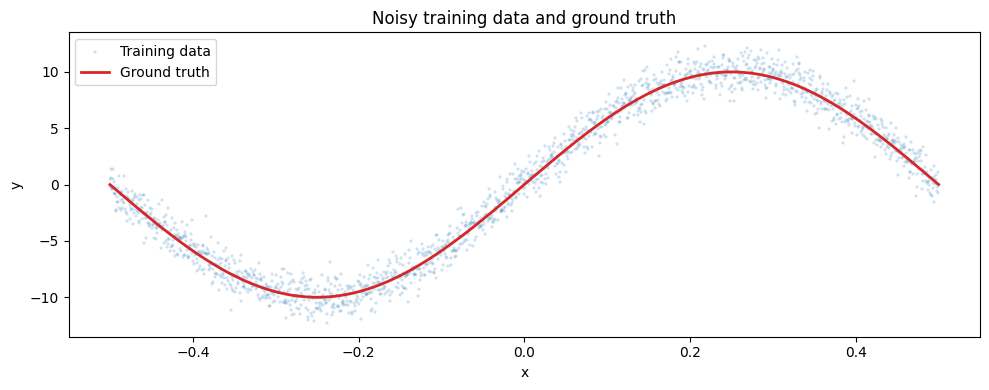

In [16]:
plt.figure(figsize=(10, 4))
plt.scatter(X_train, y_train, marker="+", s=8, linewidths=0.3, alpha=0.5, label="Training data")
plt.plot(X_train, y_true, color="tab:red", lw=2, label="Ground truth")
plt.title("Noisy training data and ground truth")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()

### 3. Variational Dense Layer

This is the core building block of our Bayesian neural network. Instead of storing a single
weight matrix $W$ and bias vector $b$, each `DenseVariational` layer maintains a **variational
posterior** $q(W, b \mid \mu, \rho)$ and samples new weights on every forward pass.

Below we detail the four theoretical components, then present the implementation.

#### 3.1 Variational Posterior $q(w)$

Each scalar weight $w_{ij}$ is independently modeled as:

$$
q(w_{ij} \mid \mu_{ij}, \rho_{ij}) = \mathcal{N}\!\left(\mu_{ij},\; \sigma_{ij}^2\right),
\qquad \sigma_{ij} = \text{softplus}(\rho_{ij}) = \log(1 + e^{\rho_{ij}})
$$

The softplus transformation guarantees $\sigma > 0$ while being smooth and differentiable
everywhere. The learnable parameters are $(\mu, \rho)$ — not $(\mu, \sigma)$ — so the
optimizer operates in unconstrained space.

#### 3.2 Scale Mixture Prior $p(w)$

Following Blundell et al. (2015), we place a **scale mixture of two Gaussians** as prior on
each weight:

$$
p(w) = \pi\, \mathcal{N}(0, \sigma_1^2) + (1 - \pi)\, \mathcal{N}(0, \sigma_2^2)
$$

where $\sigma_1 > \sigma_2$. This acts as a *soft spike-and-slab*:

- The broad component ($\sigma_1 = 1.5$) allows weights to take large values when the data
  strongly supports it.
- The narrow component ($\sigma_2 = 0.1$) pulls weights toward zero, encouraging sparsity.
- The mixing coefficient $\pi = 0.5$ balances both components equally.

The log-density of the mixture is computed via `torch.logaddexp` for numerical stability.

#### 3.3 Reparameterization Trick

Directly sampling $w \sim q(w \mid \mu, \rho)$ inside the forward pass would make the
computation graph non-differentiable with respect to $(\mu, \rho)$. The
**reparameterization trick** ([Kingma & Welling, 2014](https://arxiv.org/abs/1312.6114))
sidesteps this by writing:

$$
w = \mu + \sigma \odot \varepsilon, \qquad \varepsilon \sim \mathcal{N}(0, I)
$$

Now $w$ is a deterministic, differentiable function of $(\mu, \sigma)$ plus external noise
$\varepsilon$. Gradients flow through $\mu$ and $\sigma$ as usual, and the stochasticity
comes entirely from $\varepsilon$, which does not depend on any learnable parameter.

#### 3.4 Monte Carlo KL Divergence

The KL divergence between a Gaussian $q$ and a mixture-of-Gaussians prior $p$ has no
closed-form solution. Instead, we estimate it with a **single Monte Carlo sample** per
forward pass:

$$
\text{KL}\big[q(w) \,\|\, p(w)\big]
\approx \sum_{ij} \Big[\log q(w_{ij} \mid \mu_{ij}, \sigma_{ij}) - \log p(w_{ij})\Big]
$$

where the $w_{ij}$ are the same samples used in the forward pass. This estimator is unbiased
and, in practice, a single sample per mini-batch works well because the variance is averaged
over the many weights in the network.

#### 3.5 Implementation

The `DenseVariational` class below puts all the pieces together. On each `forward` call it:

1. Computes $\sigma = \text{softplus}(\rho)$ for kernel and bias.
2. Samples $\varepsilon \sim \mathcal{N}(0, I)$ and forms $W = \mu + \sigma \odot \varepsilon$.
3. Evaluates $\log q(W)$ and $\log p(W)$ to estimate the KL divergence.
4. Performs the linear transformation $xW + b$ and applies the activation.
5. Returns both the layer output and its KL contribution.

In [17]:
torch.manual_seed(0)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class DenseVariational(nn.Module):
    """Fully-connected layer with variational Gaussian posterior and mixture prior."""

    def __init__(
        self,
        in_features: int,
        out_features: int,
        kl_weight: float,
        activation: str | None = None,
        prior_sigma_1: float = 1.5,
        prior_sigma_2: float = 0.1,
        prior_pi: float = 0.5,
    ):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.kl_weight = float(kl_weight)

        # --- Activation function ---
        activations = {"tanh": nn.Tanh, "relu": nn.ReLU}
        if activation is None:
            self.act = nn.Identity()
        elif activation.lower() in activations:
            self.act = activations[activation.lower()]()
        else:
            raise ValueError(f"Unsupported activation: {activation}")

        # --- Mixture prior hyper-parameters ---
        self.prior_sigma_1 = float(prior_sigma_1)
        self.prior_sigma_2 = float(prior_sigma_2)
        self.prior_pi_1 = float(prior_pi)
        self.prior_pi_2 = 1.0 - self.prior_pi_1

        # Heuristic init: std ≈ sqrt of the mixture variance
        init_sigma = math.sqrt(
            self.prior_pi_1 * self.prior_sigma_1 ** 2
            + self.prior_pi_2 * self.prior_sigma_2 ** 2
        )

        # --- Variational parameters: μ and ρ (where σ = softplus(ρ)) ---
        self.kernel_mu = nn.Parameter(torch.randn(in_features, out_features) * init_sigma)
        self.kernel_rho = nn.Parameter(torch.zeros(in_features, out_features))
        self.bias_mu = nn.Parameter(torch.randn(out_features) * init_sigma)
        self.bias_rho = nn.Parameter(torch.zeros(out_features))

    def _log_mixture_prior(self, z: torch.Tensor) -> torch.Tensor:
        """Log-density of the scale mixture prior: π N(0,σ₁²) + (1-π) N(0,σ₂²)."""
        log_p1 = (
            math.log(self.prior_pi_1)
            - 0.5 * math.log(2.0 * math.pi)
            - math.log(self.prior_sigma_1)
            - 0.5 * (z / self.prior_sigma_1) ** 2
        )
        log_p2 = (
            math.log(self.prior_pi_2)
            - 0.5 * math.log(2.0 * math.pi)
            - math.log(self.prior_sigma_2)
            - 0.5 * (z / self.prior_sigma_2) ** 2
        )
        return torch.logaddexp(log_p1, log_p2)

    @staticmethod
    def _log_gaussian(x: torch.Tensor, mu: torch.Tensor, sigma: torch.Tensor) -> torch.Tensor:
        """Element-wise log-density of N(x | μ, σ²)."""
        return -0.5 * math.log(2.0 * math.pi) - torch.log(sigma) - 0.5 * ((x - mu) / sigma) ** 2

    def _sample_params_and_kl(self) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """Sample weights and bias via the reparameterization trick, return (W, b, KL)."""
        k_sigma = F.softplus(self.kernel_rho)
        b_sigma = F.softplus(self.bias_rho)

        # Reparameterization: w = μ + σ ⊙ ε
        W = self.kernel_mu + k_sigma * torch.randn_like(self.kernel_mu)
        b = self.bias_mu + b_sigma * torch.randn_like(self.bias_mu)

        # log q(w | μ, σ)  —  variational posterior density
        log_q = self._log_gaussian(W, self.kernel_mu, k_sigma).sum() + self._log_gaussian(b, self.bias_mu, b_sigma).sum()

        # log p(w)  —  mixture prior density
        log_p = self._log_mixture_prior(W).sum() + self._log_mixture_prior(b).sum()

        # Monte Carlo KL estimate (scaled by kl_weight for mini-batch correction)
        kl = self.kl_weight * (log_q - log_p)
        return W, b, kl

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        W, b, kl = self._sample_params_and_kl()
        return self.act(x @ W + b), kl

### 4. Bayesian MLP

We compose three `DenseVariational` layers into a simple multi-layer perceptron:

$$
\text{input}(1) \;\xrightarrow{\tanh}\; \text{hidden}_1(15)
\;\xrightarrow{\tanh}\; \text{hidden}_2(15)
\;\xrightarrow{\text{linear}}\; \text{output}(1)
$$

The `forward` method propagates the input through all layers, accumulating the KL
contributions from each layer into a single total KL term.

In [18]:
class BayesianMLP(nn.Module):
    """Three-layer Bayesian MLP with variational inference."""

    def __init__(
        self,
        kl_weight: float,
        prior_sigma_1: float = 1.5,
        prior_sigma_2: float = 0.1,
        prior_pi: float = 0.5,
    ):
        super().__init__()
        prior_kw = dict(prior_sigma_1=prior_sigma_1, prior_sigma_2=prior_sigma_2, prior_pi=prior_pi)
        self.l1 = DenseVariational(1, 15, kl_weight, activation="tanh", **prior_kw)
        self.l2 = DenseVariational(15, 15, kl_weight, activation="tanh", **prior_kw)
        self.out = DenseVariational(15, 1, kl_weight, activation=None, **prior_kw)

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        kl_total = torch.tensor(0.0, device=x.device)
        x, kl = self.l1(x)
        kl_total = kl_total + kl
        x, kl = self.l2(x)
        kl_total = kl_total + kl
        x, kl = self.out(x)
        kl_total = kl_total + kl
        return x, kl_total

### 5. Loss Function — Negative ELBO

In variational inference for Bayesian neural networks, the loss we minimize is the **negative
ELBO**, which decomposes into two terms:

$$
\mathcal{L}(\boldsymbol{\phi})
= \underbrace{-\sum_{i=1}^{N} \log p(y_i \mid f_{\boldsymbol{\theta}}(x_i),\, \sigma_{\text{noise}})}_{\text{Negative log-likelihood (NLL)}}
\;+\; \underbrace{\text{KL}\big[q(\boldsymbol{\theta} \mid \boldsymbol{\phi}) \,\|\, p(\boldsymbol{\theta})\big]}_{\text{Complexity cost}}
$$

**Data-fit term (NLL)**: For Gaussian observation noise with known standard deviation
$\sigma_{\text{noise}}$, the negative log-likelihood of a single observation is:

$$
-\log p(y \mid \hat{y}, \sigma) = \frac{(y - \hat{y})^2}{2\sigma^2} + \log\sigma + \frac{1}{2}\log(2\pi)
$$

**Complexity cost (KL)**: This term penalizes posteriors $q$ that deviate from the prior $p$,
acting as a natural regularizer — the Bayesian counterpart of weight decay.

When using a single batch per epoch (full-batch training), the KL weight is simply $1.0$.
For mini-batch training, it should be scaled by $1 / M$ where $M$ is the number of mini-batches.

In [19]:
def nll_gaussian(y_true: torch.Tensor, y_pred: torch.Tensor, sigma: float) -> torch.Tensor:
    """Gaussian negative log-likelihood (summed over all data points)."""
    return torch.sum(
        0.5 * ((y_true - y_pred) / sigma) ** 2
        + math.log(sigma)
        + 0.5 * math.log(2.0 * math.pi)
    )

### 6. Model Setup and Hyperparameters

We configure the model with the following choices:

| Hyperparameter | Value | Rationale |
|---|---|---|
| Architecture | 1 → 15 → 15 → 1 | Small network sufficient for 1-D regression |
| Prior $\sigma_1$ | 1.5 | Broad component allows large weights |
| Prior $\sigma_2$ | 0.1 | Narrow component encourages sparsity |
| Prior $\pi$ | 0.5 | Equal mixture of both components |
| KL weight | 1.0 | Full-batch training (single batch per epoch) |
| Learning rate | 0.08 | Relatively large; works well with Adam |
| Optimizer | Adam | Adaptive learning rates handle varying gradient scales |

In [20]:
X_t = torch.tensor(X_train, dtype=torch.float32, device=DEVICE)
y_t = torch.tensor(y_train, dtype=torch.float32, device=DEVICE)

KL_WEIGHT = 1.0
PRIOR_PARAMS = dict(prior_sigma_1=1.5, prior_sigma_2=0.1, prior_pi=0.5)

model = BayesianMLP(kl_weight=KL_WEIGHT, **PRIOR_PARAMS).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=0.08)

print(f"Device: {DEVICE}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(model)

Device: cpu
Parameters: 572
BayesianMLP(
  (l1): DenseVariational(
    (act): Tanh()
  )
  (l2): DenseVariational(
    (act): Tanh()
  )
  (out): DenseVariational(
    (act): Identity()
  )
)


### 7. Training

At each epoch the training loop performs one full-batch forward pass:

1. **Sample weights** from the variational posterior (stochastic forward pass).
2. **Compute the NLL** between predictions and targets.
3. **Add the KL divergence** to get the negative ELBO.
4. **Backpropagate** gradients through both the NLL and KL terms.
5. **Update** $(\mu, \rho)$ via Adam.

Because each forward pass draws a *different* weight sample, the loss is stochastic even
in full-batch mode. This is expected and is what allows the posterior to capture uncertainty.
Over many epochs, the variational parameters converge to a posterior that balances data fit
and prior regularization.

In [21]:
EPOCHS = 1500
mse_history: list[float] = []

model.train()
for epoch in range(EPOCHS):
    optimizer.zero_grad()
    y_pred, kl = model(X_t)
    nll = nll_gaussian(y_t, y_pred, sigma=NOISE_STD)
    loss = nll + kl  # Negative ELBO
    loss.backward()
    optimizer.step()

    mse_history.append(torch.mean((y_pred - y_t) ** 2).item())

print(f"Final MSE: {mse_history[-1]:.4f}")

Final MSE: 1.3178


### 8. Predictive Distribution via Monte Carlo

At test time, a standard neural network produces a single deterministic output. A Bayesian
neural network, by contrast, has a **distribution** over weights — so each forward pass
yields a *different* prediction. We exploit this to estimate the **predictive distribution**.

Concretely, we draw $T = 500$ weight samples from the learned variational posterior and
pass the test inputs through the network each time. This gives us $T$ predictions per test
point, from which we compute:

- **Predictive mean**: $\hat{y}(x) = \frac{1}{T} \sum_{t=1}^{T} f_{\boldsymbol{\theta}^{(t)}}(x)$
- **Epistemic uncertainty**: $\hat{\sigma}(x) = \text{std}\!\left\{f_{\boldsymbol{\theta}^{(t)}}(x)\right\}_{t=1}^{T}$

The epistemic (model) uncertainty should be **small** in regions with abundant training data
and **large** in regions far from the training distribution — exactly the behavior we want
for reliable uncertainty quantification.

We evaluate on a wider range $[-1.5, 1.5]$ to observe how uncertainty grows outside the
training domain.

In [22]:
MC_SAMPLES = 500

X_test = np.linspace(-1.5, 1.5, 1000).reshape(-1, 1)
X_test_t = torch.tensor(X_test, dtype=torch.float32, device=DEVICE)

model.eval()
y_samples: list[np.ndarray] = []

with torch.no_grad():
    for _ in tqdm.tqdm(range(MC_SAMPLES), desc="MC sampling"):
        y_s, _ = model(X_test_t)
        y_samples.append(y_s.cpu().numpy())

y_preds = np.concatenate(y_samples, axis=1)  # (1000, T)
if y_preds.ndim == 3:
    y_preds = y_preds.squeeze(-1)

y_mean = y_preds.mean(axis=1)
y_std = y_preds.std(axis=1)

MC sampling: 100%|██████████| 500/500 [00:00<00:00, 1300.31it/s]


### 9. Results Visualization

We produce two plots:

1. **Training MSE curve** — shows convergence of the data-fit component over epochs.
2. **Predictive distribution** — the mean prediction with a $\pm 2\sigma$ (≈ 95%) credible
   band. Notice how the uncertainty band widens outside the training range $[-0.5, 0.5]$,
   reflecting the model's lack of information in those regions.

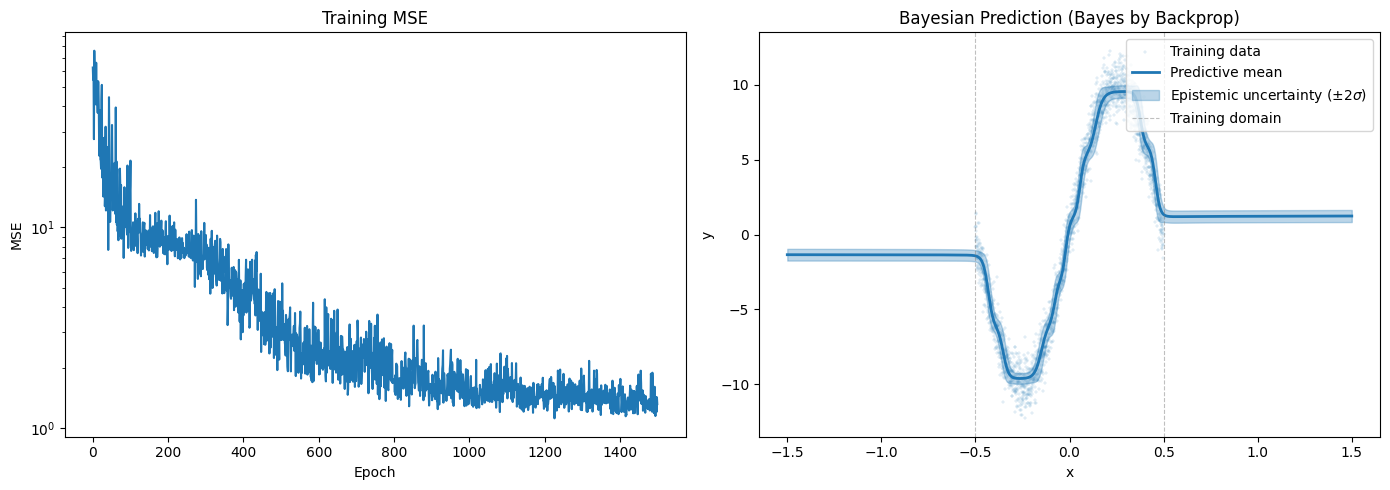

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Training MSE ---
axes[0].plot(mse_history)
axes[0].set_title("Training MSE")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")
axes[0].set_yscale("log")

# --- Predictive distribution ---
axes[1].scatter(X_train, y_train, marker="+", s=8, linewidths=0.3, alpha=0.3, label="Training data")
axes[1].plot(X_test, y_mean, color="tab:blue", lw=2, label="Predictive mean")
axes[1].fill_between(
    X_test.ravel(),
    y_mean - 2 * y_std,
    y_mean + 2 * y_std,
    alpha=0.3,
    color="tab:blue",
    label=r"Epistemic uncertainty ($\pm 2\sigma$)",
)
axes[1].axvline(-0.5, color="gray", ls="--", lw=0.8, alpha=0.5)
axes[1].axvline(0.5, color="gray", ls="--", lw=0.8, alpha=0.5, label="Training domain")
axes[1].set_title("Bayesian Prediction (Bayes by Backprop)")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()